### **Phase 1: Business Understanding**

Gold: การวิเคราะห์หาวันที่จะอยู่ในการรักษา

### **Phase 2: Data Understanding**

In [50]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os
import warnings

In [51]:
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.float_format', lambda x: '%.2f' % x)

In [52]:
df_raw = pd.read_csv('../data/raw/LengthOfStay.csv')
df_raw.head()

,eid,vdate,rcount,gender,dialysisrenalendstage,asthma,irondef,pneum,substancedependence,psychologicaldisordermajor,depress,psychother,fibrosisandother,malnutrition,hemo,hematocrit,neutrophils,sodium,glucose,bloodureanitro,creatinine,bmi,pulse,respiration,secondarydiagnosisnonicd9,discharged,facid,lengthofstay
0,1,8/29/2012,0,F,0,0,0,0,0,0,0,0,0,0,0,11.50,14.20,140.36,192.48,12.00,1.39,30.43,96,6.50,4,9/1/2012,B,3
1,2,5/26/2012,5+,F,0,0,0,0,0,0,0,0,0,0,0,9.00,4.10,136.73,94.08,8.00,0.94,28.46,61,6.50,1,6/2/2012,A,7
2,3,9/22/2012,1,F,0,0,0,0,0,0,0,0,0,0,0,8.40,8.90,133.06,130.53,12.00,1.07,28.84,64,6.50,2,9/25/2012,B,3
3,4,8/9/2012,0,F,0,0,0,0,0,0,0,0,0,0,0,11.90,9.40,138.99,163.38,12.00,0.91,27.96,76,6.50,1,8/10/2012,A,1
4,5,12/20/2012,0,F,0,0,0,1,0,1,0,0,0,0,0,9.10,9.05,138.63,94.89,11.50,1.24,30.26,67,5.60,2,12/24/2012,E,4


In [53]:
df_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 28 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   eid                         100000 non-null  int64  
 1   vdate                       100000 non-null  str    
 2   rcount                      100000 non-null  str    
 3   gender                      100000 non-null  str    
 4   dialysisrenalendstage       100000 non-null  int64  
 5   asthma                      100000 non-null  int64  
 6   irondef                     100000 non-null  int64  
 7   pneum                       100000 non-null  int64  
 8   substancedependence         100000 non-null  int64  
 9   psychologicaldisordermajor  100000 non-null  int64  
 10  depress                     100000 non-null  int64  
 11  psychother                  100000 non-null  int64  
 12  fibrosisandother            100000 non-null  int64  
 13  malnutrition              

In [54]:
df_raw.isnull().sum()

eid                           0
vdate                         0
rcount                        0
gender                        0
dialysisrenalendstage         0
asthma                        0
irondef                       0
pneum                         0
substancedependence           0
psychologicaldisordermajor    0
depress                       0
psychother                    0
fibrosisandother              0
malnutrition                  0
hemo                          0
hematocrit                    0
neutrophils                   0
sodium                        0
glucose                       0
bloodureanitro                0
creatinine                    0
bmi                           0
pulse                         0
respiration                   0
secondarydiagnosisnonicd9     0
discharged                    0
facid                         0
lengthofstay                  0
dtype: int64

In [55]:
df_raw.nunique()

eid                           100000
vdate                            367
rcount                             6
gender                             2
dialysisrenalendstage              2
asthma                             2
irondef                            2
pneum                              2
substancedependence                2
psychologicaldisordermajor         2
depress                            2
psychother                         2
fibrosisandother                   2
malnutrition                       2
hemo                               2
hematocrit                       362
neutrophils                      656
sodium                         99948
glucose                        99998
bloodureanitro                   261
creatinine                     99994
bmi                            99994
pulse                            100
respiration                      160
secondarydiagnosisnonicd9         11
discharged                       378
facid                              5
l

In [56]:
df_raw.select_dtypes(include=['category', 'object']).columns

Index(['vdate', 'rcount', 'gender', 'discharged', 'facid'], dtype='str')

In [57]:
text_cols = df_raw.select_dtypes(include=['category', 'object']).columns

# วนลูปดูว่าแต่ละคอลัมน์มีค่าอะไรบ้าง
for col in text_cols:
    print(f"🔸 {col}: {df_raw[col].unique()}")

🔸 vdate: <StringArray>
[ '8/29/2012',  '5/26/2012',  '9/22/2012',   '8/9/2012', '12/20/2012',
 '11/27/2012',  '9/27/2012',   '6/4/2012',   '7/5/2012',   '9/1/2012',
 ...
  '8/31/2012',  '3/11/2012',   '5/7/2012',   '7/4/2012',  '12/1/2012',
  '8/17/2012',  '9/26/2012',   '2/9/2012',   '4/2/2012',   '4/4/2012']
Length: 367, dtype: str
🔸 rcount: <StringArray>
['0', '5+', '1', '3', '4', '2']
Length: 6, dtype: str
🔸 gender: <StringArray>
['F', 'M']
Length: 2, dtype: str
🔸 discharged: <StringArray>
[  '9/1/2012',   '6/2/2012',  '9/25/2012',  '8/10/2012', '12/24/2012',
  '12/3/2012',  '10/3/2012',   '6/7/2012',   '7/8/2012',   '9/3/2012',
 ...
  '5/18/2012',  '4/12/2012',  '1/18/2012',   '1/4/2012',   '1/8/2013',
   '1/9/2013',  '1/12/2013',  '1/11/2013',  '1/10/2013',  '1/13/2013']
Length: 378, dtype: str
🔸 facid: <StringArray>
['B', 'A', 'E', 'D', 'C']
Length: 5, dtype: str


### **Phase 3: Data Wrangling**

In [58]:
df_processed = df_raw.copy()
df_processed.head()

,eid,vdate,rcount,gender,dialysisrenalendstage,asthma,irondef,pneum,substancedependence,psychologicaldisordermajor,depress,psychother,fibrosisandother,malnutrition,hemo,hematocrit,neutrophils,sodium,glucose,bloodureanitro,creatinine,bmi,pulse,respiration,secondarydiagnosisnonicd9,discharged,facid,lengthofstay
0,1,8/29/2012,0,F,0,0,0,0,0,0,0,0,0,0,0,11.50,14.20,140.36,192.48,12.00,1.39,30.43,96,6.50,4,9/1/2012,B,3
1,2,5/26/2012,5+,F,0,0,0,0,0,0,0,0,0,0,0,9.00,4.10,136.73,94.08,8.00,0.94,28.46,61,6.50,1,6/2/2012,A,7
2,3,9/22/2012,1,F,0,0,0,0,0,0,0,0,0,0,0,8.40,8.90,133.06,130.53,12.00,1.07,28.84,64,6.50,2,9/25/2012,B,3
3,4,8/9/2012,0,F,0,0,0,0,0,0,0,0,0,0,0,11.90,9.40,138.99,163.38,12.00,0.91,27.96,76,6.50,1,8/10/2012,A,1
4,5,12/20/2012,0,F,0,0,0,1,0,1,0,0,0,0,0,9.10,9.05,138.63,94.89,11.50,1.24,30.26,67,5.60,2,12/24/2012,E,4


In [59]:
df_processed['rcount'] =df_processed['rcount'].replace('5+', 5).astype(int)
df_processed['vdate'] = pd.to_datetime(df_processed['vdate'])
df_processed['vmonth'] = df_processed['vdate'].dt.month
df_processed['vday_of_week'] = df_processed['vdate'].dt.dayofweek
df_processed.drop(columns=['vdate', 'discharged', 'eid'], inplace=True)

In [60]:
df_processed.head()

,rcount,gender,dialysisrenalendstage,asthma,irondef,pneum,substancedependence,psychologicaldisordermajor,depress,psychother,fibrosisandother,malnutrition,hemo,hematocrit,neutrophils,sodium,glucose,bloodureanitro,creatinine,bmi,pulse,respiration,secondarydiagnosisnonicd9,facid,lengthofstay,vmonth,vday_of_week
0,0,F,0,0,0,0,0,0,0,0,0,0,0,11.50,14.20,140.36,192.48,12.00,1.39,30.43,96,6.50,4,B,3,8,2
1,5,F,0,0,0,0,0,0,0,0,0,0,0,9.00,4.10,136.73,94.08,8.00,0.94,28.46,61,6.50,1,A,7,5,5
2,1,F,0,0,0,0,0,0,0,0,0,0,0,8.40,8.90,133.06,130.53,12.00,1.07,28.84,64,6.50,2,B,3,9,5
3,0,F,0,0,0,0,0,0,0,0,0,0,0,11.90,9.40,138.99,163.38,12.00,0.91,27.96,76,6.50,1,A,1,8,3
4,0,F,0,0,0,1,0,1,0,0,0,0,0,9.10,9.05,138.63,94.89,11.50,1.24,30.26,67,5.60,2,E,4,12,3


### **Phase 4: Exploratory Data Analysis**

In [61]:
plt.figure(figsize=(10, 8))
sns.set_style('whitegrid')

<Figure size 1000x800 with 0 Axes>

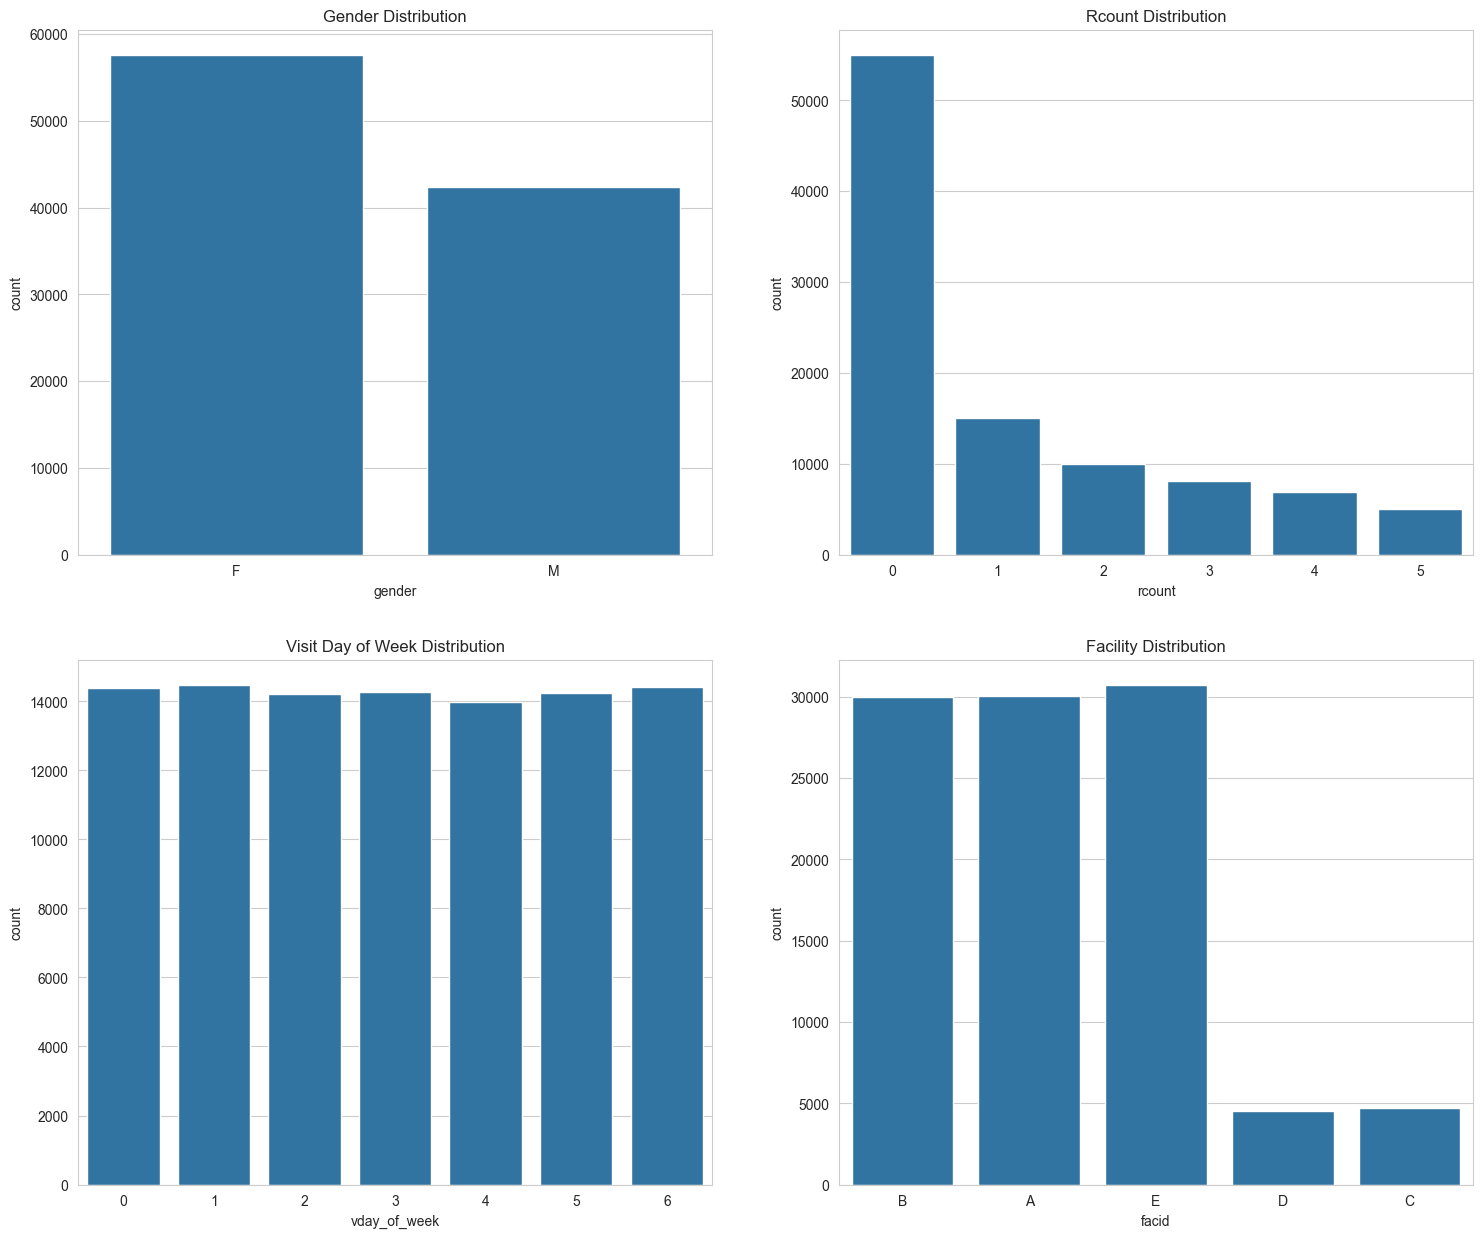

In [62]:
fig, axes = plt.subplots(2, 2, figsize=(18, 15))
sns.countplot(x='gender', data=df_processed, ax=axes[0, 0])
axes[0, 0].set_title('Gender Distribution')
sns.countplot(x='rcount', data=df_processed, ax=axes[0, 1])
axes[0, 1].set_title('Rcount Distribution')
sns.countplot(x='vday_of_week', data=df_processed, ax=axes[1, 0])
axes[1, 0].set_title('Visit Day of Week Distribution')
sns.countplot(x='facid', data=df_processed, ax=axes[1, 1])
axes[1, 1].set_title('Facility Distribution')
plt.show()

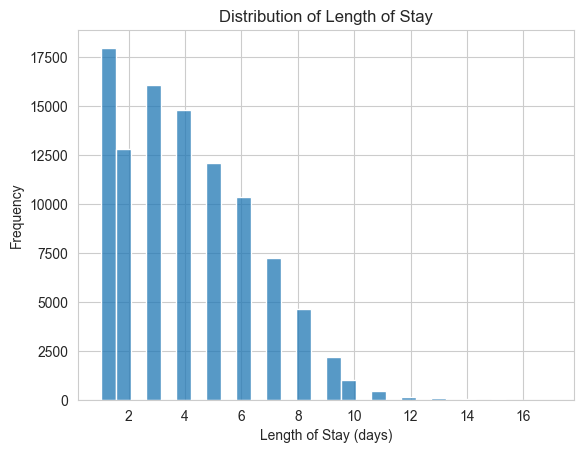

In [63]:
sns.histplot(df_processed['lengthofstay'], bins=30, kde=False)
plt.title('Distribution of Length of Stay')
plt.xlabel('Length of Stay (days)')
plt.ylabel('Frequency')
plt.show()

In [64]:
skewness = df_processed['lengthofstay'].skew()
print(f"Skewness of Length of Stay: {skewness:.2f}")

Skewness of Length of Stay: 0.63


In [65]:
df_processed['lengthofstay_log'] = np.log1p(df_processed['lengthofstay'])
df_processed['lengthofstay_log'].skew()

np.float64(-0.22110525331104894)

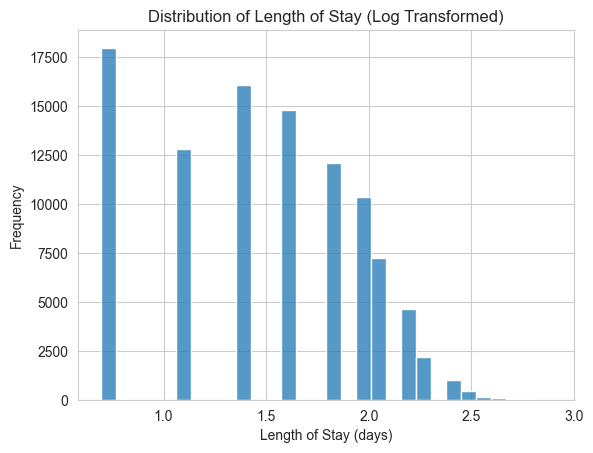

In [66]:
sns.histplot(df_processed['lengthofstay_log'], bins=30, kde=False)
plt.title('Distribution of Length of Stay (Log Transformed)')
plt.xlabel('Length of Stay (days)')
plt.ylabel('Frequency')
plt.show()

In [67]:
corr_matrix = df_processed.corr(numeric_only=True)
lengthofstay_corr = corr_matrix['lengthofstay'].sort_values(ascending=False)
print("Correlation of features with Length of Stay:")
print(lengthofstay_corr)

Correlation of features with Length of Stay:
lengthofstay                  1.00
lengthofstay_log              0.97
rcount                        0.75
psychologicaldisordermajor    0.29
hemo                          0.22
irondef                       0.19
psychother                    0.19
malnutrition                  0.17
dialysisrenalendstage         0.17
bloodureanitro                0.15
substancedependence           0.15
pneum                         0.14
depress                       0.12
asthma                        0.08
fibrosisandother              0.06
pulse                         0.01
secondarydiagnosisnonicd9     0.01
vday_of_week                  0.00
vmonth                        0.00
bmi                           0.00
glucose                      -0.00
sodium                       -0.00
creatinine                   -0.00
neutrophils                  -0.01
respiration                  -0.02
hematocrit                   -0.06
Name: lengthofstay, dtype: float64


### **Phase 5: Feature Engineering**

In [68]:
df_processed =pd.get_dummies(df_processed, columns=['gender', 'facid'], drop_first=True)

In [69]:
df_processed.head()

,rcount,dialysisrenalendstage,asthma,irondef,pneum,substancedependence,psychologicaldisordermajor,depress,psychother,fibrosisandother,malnutrition,hemo,hematocrit,neutrophils,sodium,glucose,bloodureanitro,creatinine,bmi,pulse,respiration,secondarydiagnosisnonicd9,lengthofstay,vmonth,vday_of_week,lengthofstay_log,gender_M,facid_B,facid_C,facid_D,facid_E
0,0,0,0,0,0,0,0,0,0,0,0,0,11.50,14.20,140.36,192.48,12.00,1.39,30.43,96,6.50,4,3,8,2,1.39,False,True,False,False,False
1,5,0,0,0,0,0,0,0,0,0,0,0,9.00,4.10,136.73,94.08,8.00,0.94,28.46,61,6.50,1,7,5,5,2.08,False,False,False,False,False
2,1,0,0,0,0,0,0,0,0,0,0,0,8.40,8.90,133.06,130.53,12.00,1.07,28.84,64,6.50,2,3,9,5,1.39,False,True,False,False,False
3,0,0,0,0,0,0,0,0,0,0,0,0,11.90,9.40,138.99,163.38,12.00,0.91,27.96,76,6.50,1,1,8,3,0.69,False,False,False,False,False
4,0,0,0,0,1,0,1,0,0,0,0,0,9.10,9.05,138.63,94.89,11.50,1.24,30.26,67,5.60,2,4,12,3,1.61,False,False,False,False,True


In [70]:
SAVE_PATH = '../data/processed/df_processed.csv'
os.makedirs(os.path.dirname(SAVE_PATH), exist_ok=True)
df_processed.to_csv(SAVE_PATH, index=False)
print(f"Processed data saved to: {SAVE_PATH}")

Processed data saved to: ../data/processed/df_processed.csv
